In [4]:
# Install libraries (skip if already installed in your environment)
# !pip install pandas numpy scikit-learn nltk matplotlib seaborn joblib

import pandas as pd
import numpy as np
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import joblib

# One-time NLTK downloads
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

print("Environment ready ✅")


Environment ready ✅


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yalal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\yalal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\yalal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yalal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yalal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [19]:
df = pd.read_csv("Amazon_Reviews.csv",engine='python')   # your actual file path
print(df.columns.tolist())
df.head()

['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [20]:
df['review'] = df['Review Title'].fillna('') + '. ' + df['Review Text'].fillna('')
df[['Review Title', 'Review Text', 'review']].head()


,Review Title,Review Text,review
0,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...",A Store That Doesn't Want to Sell Anything. I ...
1,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,Had multiple orders one turned up and…. Had mu...
2,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,I informed these reprobates. I informed these ...
3,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,Advertise one price then increase it on websit...
4,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,If I could give a lower rate I would. If I cou...


In [21]:
def extract_rating(text):
    match = re.search(r'(\d+)', str(text))
    return int(match.group(1)) if match else np.nan

df['rating_num'] = df['Rating'].apply(extract_rating)
print(df['rating_num'].value_counts().sort_index())
print("Missing/unparsed ratings:", df['rating_num'].isna().sum())

# Drop any rows where the rating couldn't be parsed
df = df.dropna(subset=['rating_num']).reset_index(drop=True)


rating_num
1.0    13123
2.0     1227
3.0      885
4.0     1292
5.0     4528
Name: count, dtype: int64
Missing/unparsed ratings: 159


In [22]:
def rating_to_sentiment(r):
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating_num'].apply(rating_to_sentiment)
print(df['sentiment'].value_counts())


sentiment
negative    14350
positive     5820
neutral       885
Name: count, dtype: int64


Missing values:
 review       0
sentiment    0
dtype: int64
Duplicate reviews: 34


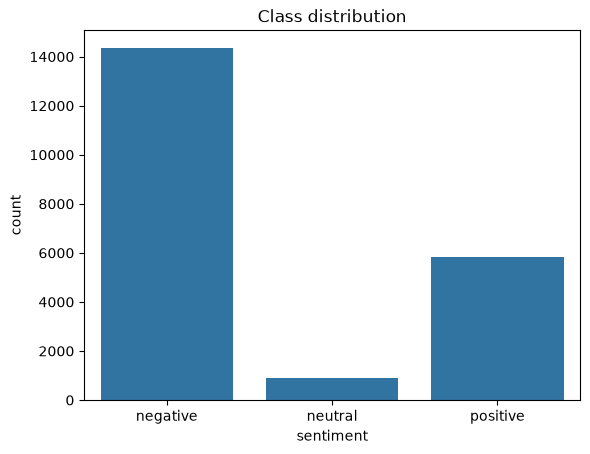

In [ ]:
# Visualize class distribution
print("Missing values:\n", df[['review', 'sentiment']].isnull().sum())
print("Duplicate reviews:", df['review'].duplicated().sum())

sns.countplot(x='sentiment', data=df, order=['negative', 'neutral', 'positive'])
plt.title("Class distribution")
plt.show()


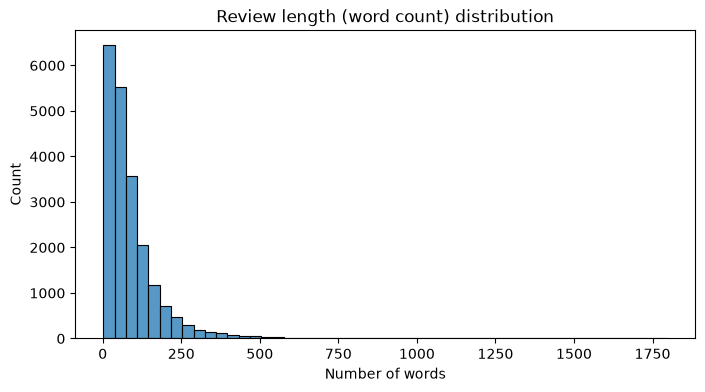

count    21055.000000
mean        89.241273
std         94.702626
min          2.000000
25%         31.000000
50%         62.000000
75%        113.000000
max       1796.000000
Name: review_len, dtype: float64


In [24]:
df['review_len'] = df['review'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,4))
sns.histplot(df['review_len'], bins=50)
plt.title("Review length (word count) distribution")
plt.xlabel("Number of words")
plt.show()
print(df['review_len'].describe())


In [25]:
#Data preprocessing and cleaning 
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase, strip HTML tags and non-letter characters."""
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML tags e.g. <br />
    text = text.lower()
    text = re.sub(r"[^a-z\s]", ' ', text)       # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()    # collapse whitespace
    return text

def preprocess(text: str) -> str:
    """Full pipeline: clean -> tokenize -> remove stopwords -> lemmatize."""
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens
              if tok not in stop_words and len(tok) > 2]
    return ' '.join(tokens)

# Quick sanity check
sample_text = df['review'][0]
print("BEFORE:\n", sample_text[:300])
print("\nAFTER:\n", preprocess(sample_text)[:300])


BEFORE:
 A Store That Doesn't Want to Sell Anything. I registered on the website, tried to order a laptop, entered all the details, but instead of charging me and sending the product, they froze my account, demanding various verification documents. I sent them over. They said they would review them within 24

AFTER:
 store want sell anything registered website tried order laptop entered detail instead charging sending product froze account demanding various verification document sent said would review within hour reality week one help give truthful estimate resolved tell wait never seen horrible marketplace life


In [26]:
# Apply to the full dataset (~50,000 rows). This takes roughly 1-2 minutes.
t0 = time.time()
df['clean_review'] = df['review'].apply(preprocess)
print(f"Done in {time.time() - t0:.1f}s")

df[['review', 'clean_review', 'sentiment']].head()


Done in 12.3s


,review,clean_review,sentiment
0,A Store That Doesn't Want to Sell Anything. I ...,store want sell anything registered website tr...,negative
1,Had multiple orders one turned up and…. Had mu...,multiple order one turned multiple order one t...,negative
2,I informed these reprobates. I informed these ...,informed reprobate informed reprobate would go...,negative
3,Advertise one price then increase it on websit...,advertise one price increase website bought am...,negative
4,If I could give a lower rate I would. If I cou...,could give lower rate would could give lower r...,negative


In [27]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
label_map_inv = {v: k for k, v in label_map.items()}

df['label'] = df['sentiment'].map(label_map)
df[['clean_review', 'label']].head()


,clean_review,label
0,store want sell anything registered website tr...,0
1,multiple order one turned multiple order one t...,0
2,informed reprobate informed reprobate would go...,0
3,advertise one price increase website bought am...,0
4,could give lower rate would could give lower r...,0


In [28]:
#Feature extraction using TF-IDF
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

tfidf = TfidfVectorizer(
    max_features=10000,   # vocabulary size cap
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=5,             # ignore very rare terms
    max_df=0.8            # ignore overly common terms
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)


Train size: 16844 | Test size: 4211
TF-IDF matrix shape (train): (16844, 10000)


In [29]:
#model training and evaluation
model = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)
print("Model trained ✅")


y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy:       {acc:.4f}")
print(f"Macro Precision:{prec:.4f}")
print(f"Macro Recall:   {rec:.4f}")
print(f"Macro F1-score: {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))


Model trained ✅
Accuracy:       0.8713
Macro Precision:0.6666
Macro Recall:   0.6926
Macro F1-score: 0.6726

              precision    recall  f1-score   support

    negative       0.95      0.91      0.93      2870
     neutral       0.16      0.30      0.21       177
    positive       0.89      0.87      0.88      1164

    accuracy                           0.87      4211
   macro avg       0.67      0.69      0.67      4211
weighted avg       0.90      0.87      0.88      4211



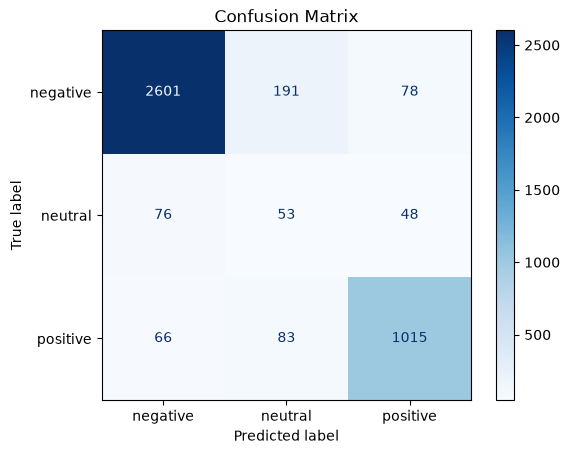

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [31]:
#hyperparameter tuning using GridSearchCV
param_grid = {'C': [0.1, 1, 5, 10]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train_tfidf, y_train)

print("Best C:", grid.best_params_['C'])
print("Best CV accuracy:", grid.best_score_)

best_model = grid.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test_tfidf))
print("Test accuracy with best model:", test_acc)


Best C: 5
Best CV accuracy: 0.9133816013331383
Test accuracy with best model: 0.9118974115412016


In [32]:
#Model persistence: save the trained model and TF-IDF vectorizer for future use
joblib.dump(best_model, 'sentiment_model.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
print("Saved sentiment_model.joblib and tfidf_vectorizer.joblib")


Saved sentiment_model.joblib and tfidf_vectorizer.joblib


In [34]:
def predict_sentiment(text: str, model=best_model, vectorizer=tfidf) -> dict:
    cleaned = preprocess(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    return {
        'text': text,
        'sentiment': label_map_inv[pred],
        'confidence': round(float(max(proba)), 4)
    }

samples = [
    "This product completely exceeded my expectations, I love it!",
    "Absolutely terrible experience, would not recommend to anyone.",
    "It's okay, does the job but nothing special."
]

for s in samples:
    print(predict_sentiment(s))


{'text': 'This product completely exceeded my expectations, I love it!', 'sentiment': 'positive', 'confidence': 0.8653}
{'text': 'Absolutely terrible experience, would not recommend to anyone.', 'sentiment': 'negative', 'confidence': 0.9479}
{'text': "It's okay, does the job but nothing special.", 'sentiment': 'neutral', 'confidence': 0.7506}
